## **DATA SCRAPING**

In [ ]:
pip install google-play-scraper

In [ ]:
import pandas as pd
from google_play_scraper import reviews, Sort

In [ ]:
com.mobile.legends

**DATA NEGARA INDONESIA**

In [ ]:
app_id = 'com.mobile.legends'

def get_reviews_by_date(
    app_id,
    lang='id',
    country='id',
    count=10000,
    start_date='2026-03-28',
    end_date='2026-04-15'
):

    all_reviews = []
    continuation_token = None

    start_dt = datetime.strptime(start_date, '%Y-%m-%d')
    end_dt = datetime.strptime(end_date, '%Y-%m-%d')

    while True:
        try:
            result, continuation_token = reviews(
                app_id,
                lang=lang,
                country=country,
                sort=Sort.NEWEST,
                count=count,
                continuation_token=continuation_token
            )

            if not result:
                break

            for r in result:

                review_date = r.get('at')

                if review_date is None:
                    continue

                if start_dt <= review_date <= end_dt:

                    rec = {
                        'username': r.get('userName'),
                        'rating': r.get('score'),
                        'review': r.get('content'),
                        'date': review_date
                    }

                    all_reviews.append(rec)

                elif review_date < start_dt:
                    continuation_token = None
                    break

            if continuation_token is None:
                break

        except Exception as e:
            print("Error:", e)
            break

    return all_reviews

In [ ]:
from datetime import datetime

In [ ]:
data = get_reviews_by_date(app_id)

df_id = pd.DataFrame(data)

In [ ]:
df_id['negara'] = 'Indonesia'

In [ ]:
df_id.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22135 entries, 0 to 22134
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   username  22135 non-null  object        
 1   rating    22135 non-null  int64         
 2   review    22135 non-null  object        
 3   date      22135 non-null  datetime64[ns]
 4   negara    22135 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 864.8+ KB


**DATA NEGARA FILIPINA**

In [ ]:
app_id = 'com.mobile.legends'

def get_reviews_by_date(
    app_id,
    lang='ph',
    country='ph',
    count=10000,
    start_date='2026-03-28',
    end_date='2026-05-01'
):

    all_reviews = []
    continuation_token = None

    start_dt = datetime.strptime(start_date, '%Y-%m-%d')
    end_dt = datetime.strptime(end_date, '%Y-%m-%d')

    while True:
        try:
            result, continuation_token = reviews(
                app_id,
                lang=lang,
                country=country,
                sort=Sort.NEWEST,
                count=count,
                continuation_token=continuation_token
            )

            if not result:
                break

            for r in result:

                review_date = r.get('at')

                if review_date is None:
                    continue

                if start_dt <= review_date <= end_dt:

                    rec = {
                        'username': r.get('userName'),
                        'rating': r.get('score'),
                        'review': r.get('content'),
                        'date': review_date
                    }

                    all_reviews.append(rec)

                elif review_date < start_dt:
                    continuation_token = None
                    break

            if continuation_token is None:
                break

        except Exception as e:
            print("Error:", e)
            break

    return all_reviews

In [ ]:
data = get_reviews_by_date(app_id)

df_ph = pd.DataFrame(data)

In [ ]:
df_ph['negara'] = 'Filipina'

In [ ]:
df_ph.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20656 entries, 0 to 20655
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   username  20656 non-null  object        
 1   rating    20656 non-null  int64         
 2   review    20656 non-null  object        
 3   date      20656 non-null  datetime64[ns]
 4   negara    20656 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 807.0+ KB


In [ ]:
df_ph = pd.DataFrame(result_ph)
df_ph['negara'] = 'Filipina'

In [ ]:
df = pd.concat([df_id, df_ph], ignore_index=True)

In [ ]:
df

,username,rating,review,date,negara
0,Pengguna Google,5,memang bagus sekali kali,2026-04-14 23:58:54,Indonesia
1,Pengguna Google,4,Game nya seru tapi banyak bocil dark system',2026-04-14 23:58:02,Indonesia
2,Pengguna Google,5,yg ini sudah bagus dan draft pick dah mulai se...,2026-04-14 23:49:31,Indonesia
3,Pengguna Google,1,"lawan di kasih tidak seimbang ,Hero kita tidak...",2026-04-14 23:48:30,Indonesia
4,Pengguna Google,4,game ini bagus tapi juga keburukan seperti dar...,2026-04-14 23:44:59,Indonesia
...,...,...,...,...,...
42786,A Google user,5,I LIKE TO MOVE IT MOVE IT,2026-03-28 00:18:05,Filipina
42787,A Google user,1,sebab sat menang sat kalah apa benda,2026-03-28 00:16:27,Filipina
42788,A Google user,1,"Tbh the game is great, but there is this issue...",2026-03-28 00:14:03,Filipina
42789,A Google user,1,it's does it working in mlbb,2026-03-28 00:09:05,Filipina


In [ ]:
df.to_csv("review_mobile_legends.csv", index=False)

## **DATA CLEANING**

In [ ]:
import pandas as pd
df=pd.read_csv("review_mobile_legends.csv")

In [ ]:
df.isnull().sum()

,0
username,0
rating,0
review,0
date,0
negara,0


In [ ]:
df = df.dropna(subset=['review'])

In [ ]:
import re

def clean_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)  # hapus link

    text = re.sub(r'\d+', '', text)  # hapus angka

    text = re.sub(r'[^\w\s]', '', text)  # hapus tanda baca

    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean_review'] = df['review'].apply(clean_text)

In [ ]:
df[['review','clean_review']].head()

,review,clean_review
0,memang bagus sekali kali,memang bagus sekali kali
1,Game nya seru tapi banyak bocil dark system',game nya seru tapi banyak bocil dark system
2,yg ini sudah bagus dan draft pick dah mulai se...,yg ini sudah bagus dan draft pick dah mulai se...
3,"lawan di kasih tidak seimbang ,Hero kita tidak...",lawan di kasih tidak seimbang hero kita tidak ...
4,game ini bagus tapi juga keburukan seperti dar...,game ini bagus tapi juga keburukan seperti dar...


In [ ]:
def label_sentimen(rating):

    if rating <= 3:
        return "negatif"
    else:
        return "positif"

df['sentimen_rating'] = df['rating'].apply(label_sentimen)

In [ ]:
df.head()

,username,rating,review,date,negara,clean_review,sentimen_rating
0,Pengguna Google,5,memang bagus sekali kali,2026-04-14 23:58:54,Indonesia,memang bagus sekali kali,positif
1,Pengguna Google,4,Game nya seru tapi banyak bocil dark system',2026-04-14 23:58:02,Indonesia,game nya seru tapi banyak bocil dark system,positif
2,Pengguna Google,5,yg ini sudah bagus dan draft pick dah mulai se...,2026-04-14 23:49:31,Indonesia,yg ini sudah bagus dan draft pick dah mulai se...,positif
3,Pengguna Google,1,"lawan di kasih tidak seimbang ,Hero kita tidak...",2026-04-14 23:48:30,Indonesia,lawan di kasih tidak seimbang hero kita tidak ...,negatif
4,Pengguna Google,4,game ini bagus tapi juga keburukan seperti dar...,2026-04-14 23:44:59,Indonesia,game ini bagus tapi juga keburukan seperti dar...,positif


In [ ]:
df.to_csv("clean review_mobile_legends.csv", index=False)

In [ ]:
pd.crosstab(df['negara'], df['sentimen_rating'])

sentimen_rating,negatif,positif
negara,,
Filipina,12637,8019
Indonesia,12922,9213


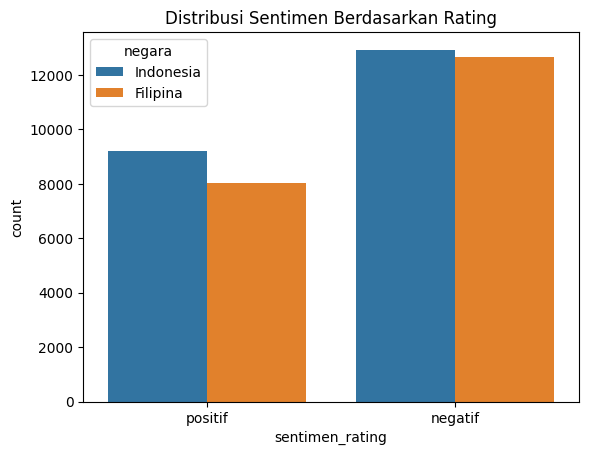

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='sentimen_rating', hue='negara')

plt.title("Distribusi Sentimen Berdasarkan Rating")
plt.show()

In [ ]:
df['negara'].value_counts()

,count
negara,
Indonesia,22135
Filipina,20656


## **DATA TRANSLATION**

In [ ]:
df = pd.concat([df_id, df_ph], ignore_index=True)

In [ ]:
df=pd.read_csv("clean review_mobile_legends.csv")

In [ ]:
pip install deep-translator tqdm

In [ ]:
import pandas as pd
from deep_translator import GoogleTranslator
from tqdm import tqdm

In [ ]:
tqdm.pandas()

In [ ]:
translator = GoogleTranslator(source='auto', target='en')

def translate_text(text):

    try:
        return translator.translate(text)

    except:
        return text

In [ ]:
df['review_translate'] = df['clean_review'].progress_apply(translate_text)

 77%|███████▋  | 33138/42791 [3:50:50<58:46,  2.74it/s]  

In [ ]:
df.to_csv("mlbb_review_translated.csv", index=False)

## **ROBERTA**

In [ ]:
import pandas as pd

In [ ]:
df_1=pd.read_csv("/content/translate_gabungan_indo_ph.csv")

In [ ]:
#df_1=pd.read_csv("clean review_mobile_legends.csv")

In [ ]:
pip install transformers torch

In [ ]:
from transformers import pipeline

In [ ]:
sentiment = pipeline(
    "text-classification",
    model="textattack/roberta-base-SST-2"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: textattack/roberta-base-SST-2
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
from tqdm import tqdm

# Ambil teks review
texts = df_1['review_translate'].fillna("").astype(str).tolist()

batch_size = 32
predictions = []

# Prediksi RoBERTa per batch
for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i+batch_size]

    results = sentiment(
        batch,
        truncation=True,   # otomatis potong >512 token
        padding=True,
        max_length=512     # Menambahkan max_length untuk memastikan input tidak melebihi batas model
    )

    for r in results:
        predictions.append(r['label'])

# Simpan hasil ke dataframe
df_1['prediksi_roberta'] = predictions

100%|██████████| 1330/1330 [1:54:19<00:00,  5.16s/it]


In [ ]:
df_1.to_csv("prediksi_roberta.csv", index=False)

In [ ]:
from google.colab import files
files.download('prediksi_roberta.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_1[['review_translate','prediksi_roberta']]

,review_translate,prediksi_roberta
0,moonton please fix matchmaking im frustated te...,LABEL_0
1,the service is so sucks i already reported my ...,LABEL_0
2,it can make your brain crazy,LABEL_0
3,this game is so niceee,LABEL_1
4,ml gmpng many dark systems,LABEL_0
...,...,...
42535,the game likes to run alone even though the ne...,LABEL_0
42536,"I don't know why the more it is updated, inste...",LABEL_0
42537,exciting,LABEL_1
42538,just a fun game,LABEL_1


In [ ]:
df_1['prediksi_roberta'].unique()

array(['LABEL_0', 'LABEL_1'], dtype=object)

In [ ]:
def simplify_sentiment(label):
    if label == "LABEL_0":
        return "negatif"
    elif label == "LABEL_1":
        return "positif"
    else:
        return None # Handle unexpected labels if any

df_1["sentimen_final"] = df_1["prediksi_roberta"].apply(simplify_sentiment)

In [ ]:
pd.crosstab(df_1['negara'], df_1['sentimen_final'], normalize='index') * 100

sentimen_final,negatif,positif
negara,,
Filipina,60.759741,39.240259
Indonesia,63.282349,36.717651


In [ ]:
pd.crosstab(
    [df_1['negara'], df_1['sentimen_rating']],
    df_1['sentimen_final'],
    normalize='index'
) * 100

sentimen_final               negatif    positif
negara    sentimen_rating                      
Filipina  negatif          88.887126  11.112874
          positif          15.873418  84.126582
Indonesia negatif          83.723272  16.276728
          positif          34.367123  65.632877

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_true = df_1['sentimen_rating']
y_pred = df_1['sentimen_final']

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.814480488951575
Precision: 0.8134211552774443
Recall   : 0.814480488951575
F1 Score : 0.8135831549667759


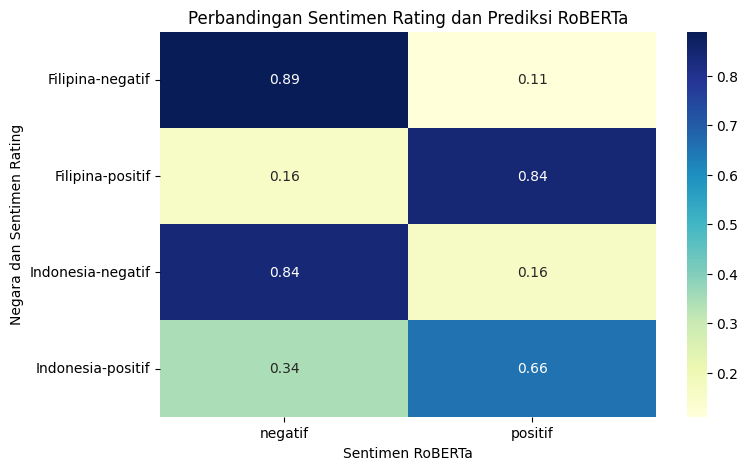

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

tab = pd.crosstab(
    [df_1['negara'], df_1['sentimen_rating']],
    df_1['sentimen_final'],
    normalize='index'
)

plt.figure(figsize=(8,5))

sns.heatmap(tab, annot=True, cmap="YlGnBu")

plt.title("Perbandingan Sentimen Rating dan Prediksi RoBERTa")
plt.xlabel("Sentimen RoBERTa")
plt.ylabel("Negara dan Sentimen Rating")

plt.show()

In [ ]:
# Filter sarkas
df_sarkas = df_1[
    (
        (df_1['sentimen_rating'] == 'positif') &
        (df_1['sentimen_final'] == 'negatif')
    ) |
    (
        (df_1['sentimen_rating'] == 'negatif') &
        (df_1['sentimen_final'] == 'positif')
    )
]

In [ ]:
df_sarkas[['negara', 'review_translate', 'rating', 'sentimen_final']].head(10)

,negara,review_translate,rating,sentimen_final
7,Filipina,lol,5,negatif
12,Filipina,nice game but the problems are the dark systems,5,negatif
23,Filipina,for the team it's good damn,1,positif
27,Filipina,we want estes,1,positif
35,Filipina,ml u hv to fix the new server problem i play m...,5,negatif
47,Filipina,ok,5,negatif
48,Filipina,ive been playing mobile legends since and im s...,5,negatif
54,Filipina,well this is the best moba on mobile firstly t...,3,positif
66,Filipina,mlbb basic ulita,5,negatif
72,Filipina,easy matchmaking,1,positif


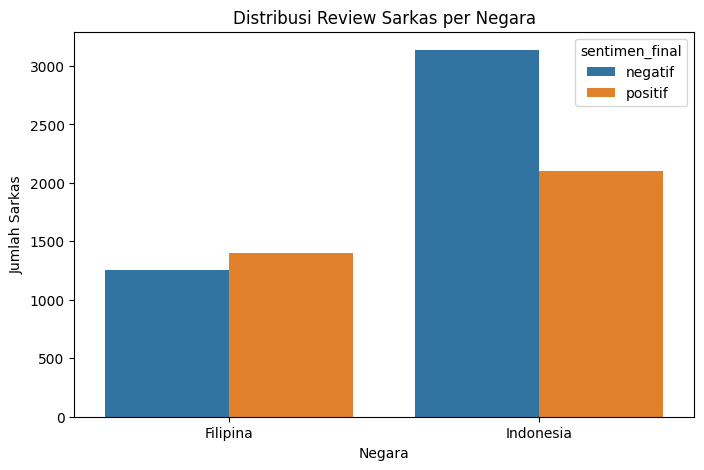

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_sarkas,
    x='negara',
    hue='sentimen_final'
)

plt.title("Distribusi Review Sarkas per Negara")
plt.xlabel("Negara")
plt.ylabel("Jumlah Sarkas")

plt.show()

**PREPROCESSING WORDCLOUD**

In [ ]:
!pip install Sastrawi
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

In [ ]:
factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())
stopwords.update(["game","mobile","legend","ml","yg","aja","di","tapi","maka","ke","dari","ini","itu","saya","dan","nya","player","montoon","monton","moonton","gua","ga","gak","gw","aku"])

In [ ]:
def clean_text(text):

    text = text.lower()  # lowercase
    text = re.sub(r'\d+', '', text)  # hapus angka
    text = re.sub(r'[^\w\s]', '', text)  # hapus tanda baca

    words = text.split()

    words = [word for word in words if word not in stopwords]

    return " ".join(words)

In [ ]:
df_1["clean_review"] = df_1["review"].astype(str).apply(clean_text)

In [ ]:
positif = df_1[df_1["sentimen_final"]=="positif"]["clean_review"]
negatif = df_1[df_1["sentimen_final"]=="negatif"]["clean_review"]

In [ ]:
positif_text = " ".join(positif)
negatif_text = " ".join(negatif)

# **WORDCLOUD POSITIF**

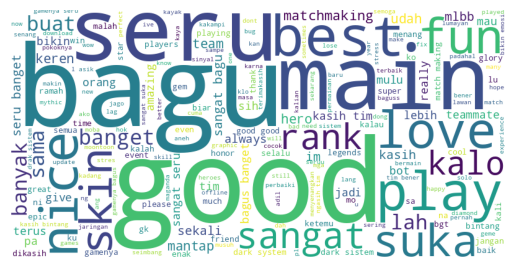

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(width=800, height=400, background_color="white").generate(positif_text)

plt.imshow(wc)
plt.axis("off")
plt.show()

**WORDCLOUD NEGATIF**

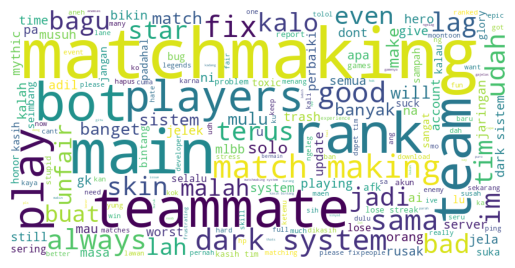

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(width=800, height=400, background_color="white").generate(negatif_text)

plt.imshow(wc)
plt.axis("off")
plt.show()

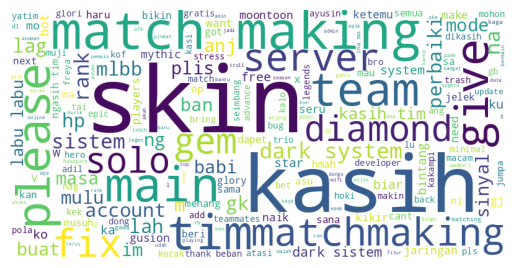

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc = WordCloud(width=800, height=400, background_color="white").generate(netral_text)

plt.imshow(wc)
plt.axis("off")
plt.show()

# **WORDCloud indonesia dan filipina**

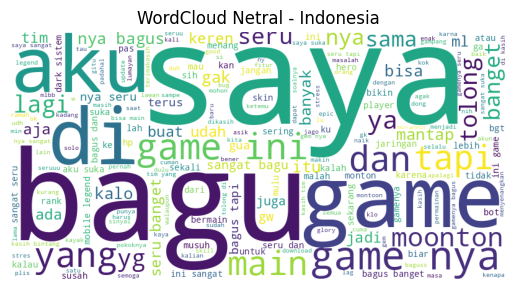

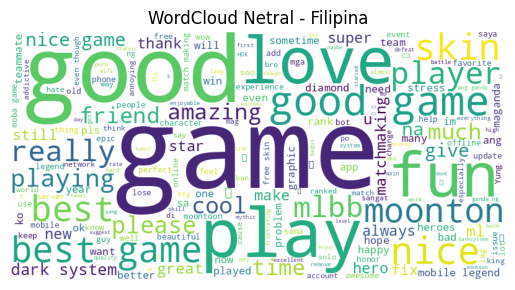

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for negara in df_1['negara'].unique():
    text = " ".join(df_1[
        (df_1['negara'] == negara) &
        (df['sentimen_rating'] == 'positif')
    ]['review'])

    wc = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure()
    plt.imshow(wc)
    plt.title(f"WordCloud Netral - {negara}")
    plt.axis("off")
    plt.show()

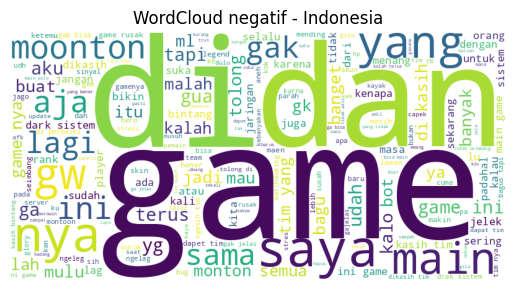

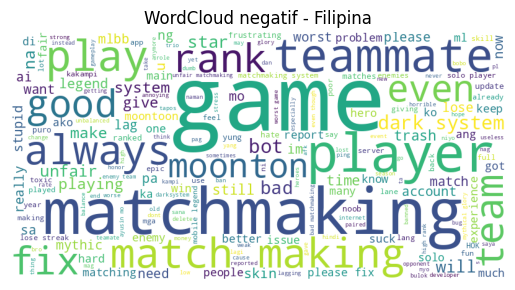

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for negara in df_1['negara'].unique():
    text = " ".join(df_1[
        (df_1['negara'] == negara) &
        (df['sentimen_rating'] == 'negatif')
    ]['review'])

    wc = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure()
    plt.imshow(wc)
    plt.title(f"WordCloud negatif - {negara}")
    plt.axis("off")
    plt.show()